# 🌊 Hydrologimodellering i Geofag 1

I denne notatboka skal me bruka Python til å utforska vassføringsdata frå NVE. Me startar med data frå **Reinsnosvatn** (Ullensvang, Vestland) — daglege målingar sidan 1917.

| Del | Tema |
|-----|------|
| **Del 1** | Lesa inn og utforska eit stort datasett |
| **Del 2** | Rekna ut **middelflom** og sjå korleis den utviklar seg |
| **Del 3** | **Lineær modell**, **flomtypar** (20-/100-årsflom) og **hydrogram** |
| **Del 4** | Gjera det same med **eiga elv** 🔍 |
| **Del 5** | Skriva ein kort analyse og tolking |

<div class="alert alert-block alert-info">
<b>📌 Slik brukar du notatboka:</b> Køyr cellene i rekkefølgje (Shift+Enter). Celler merka med <b>✏️</b> er oppgåver der du skal skriva eller fylla inn noko. Celler merka med <b>🔢</b> inneheld matematikk.
</div>

---
## Del 1: Importera og utforska data

Me startar med å importera biblioteka me treng:
- `pandas` — jobbe med tabellar (datarammer)
- `matplotlib` — lage figurar
- `numpy` — matematikk

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Lesa inn CSV-fila

CSV-fila frå NVE brukar:
- Semikolon (`;`) for å skilja kolonnene
- Komma som desimalteikn
- To rader med overskrift før dataa startar

Køyr cella under for å lesa inn dataa i ei **dataramme** (`df`).

In [2]:
df = pd.read_csv(
    "vassforing_reinsnos_dogn.csv", 
    sep = ";", 
    skiprows = 2, 
    names = ["dato", "Vassføring", "Korrigert", "Kontrollert"], 
    parse_dates = True, 
    decimal = ","
)

# Gjer dato-kolonnen om til ein dato-indeks
df.index = pd.to_datetime(df['dato']) 
df.index = pd.to_datetime(df.index.date)

# Fjernar kolonnene me ikkje treng
df = df.drop(columns = ["dato", "Korrigert", "Kontrollert"])

### ✏️ Predict

**Før du køyrer neste celle:** Kva trur du `df.tail()` viser? Skriv svaret ditt her:

*Svar:* 

In [3]:
df.tail()

,Vassføring
2025-12-26,3.553918
2025-12-27,3.214202
2025-12-28,2.840203
2025-12-29,2.525122
2025-12-30,2.256700


**Stemte prediksjonen din?** Kva viser tabellen?

*Svar:* 

### Plotta alle data

La oss prøva å plotta alle målingane:

### ✏️ Predict

**Før du køyrer:** Kva trur du grafen kjem til å sjå ut når me plottar alle nærare 40 000 målingane samstundes? Vil det vera lett å lesa av noko?

*Svar:* 

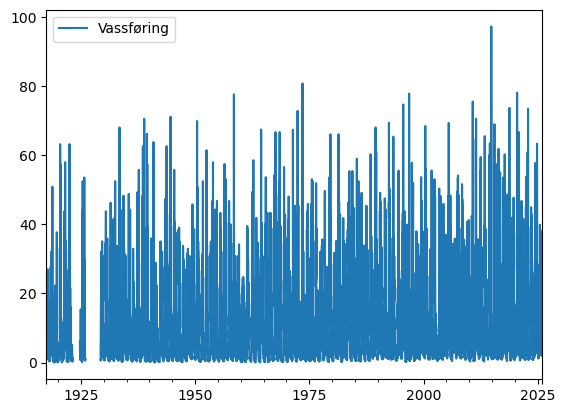

In [4]:
df.plot();

---
## Del 2: Middelflom

> **Middelflom** = gjennomsnittet av høgaste vassføring per år over ein lang årserie.

For å finna middelflommen treng me to steg:
1. Finna den høgaste vassføringa kvart år
2. Ta gjennomsnittet over mange år (t.d. 30 år)

<div class="alert alert-block alert-success">
<b>💡 Kvifor 30 år?</b> Same logikk som klimanormalar — einskildår kan vera spesielle (ekstremt vått eller tørt). Med 30 år jamnar vi ut tilfeldige variasjonar og finn det «normale».
</div>

### Steg 1: Høgaste vassføring per år

`groupby` deler dataa i grupper (her: per år) og finn `max` i kvar gruppe.

In [5]:
årleg_vf_maks = df.groupby(by=[df.index.year]).max()
årleg_vf_maks.head()

,Vassføring
1917,26.98031
1918,50.93218
1919,37.72713
1920,63.26006
1921,58.04514


### ✏️ Spørsmål

Kor mange rader har den nye tabellen? (Tenk: kor mange år med data har me?)

*Svar:* 

### Plotta årleg maksimal vassføring

### Fjerna manglande data

Det manglar data frå delar av 1920-talet. Me avgrensar til åra med gode data.

<div class="alert alert-block alert-info">
<b>👀 Tips:</b> Sjå på figuren du laga ovanfor — kvar er det eit tydeleg «hol» i dataa? Vel eit startår etter holet og eit sluttår som er 2025 (no har me data heile vegen til desember 2025!).
</div>

**Fyll inn** startår og sluttår:

### ✏️ Fyll inn: Avgrens dataa

**Fyll inn startår og sluttår** basert på det du ser i figuren:

In [6]:
# Fyll inn riktige årstal:
startår = ___
sluttår = ___

årleg_vf_maks = årleg_vf_maks.loc[startår:sluttår]
årleg_vf_maks.head()

,Vassføring


### Steg 2: Rullande gjennomsnitt (middelflom)

`rolling(window=30)` ser på dei 30 siste åra for kvar rad, og `mean()` reknar ut gjennomsnittet.

Tenk på det som eit vindauge som er 30 år breitt som skyv seg framover i tid.

In [7]:
maksvf_og_middelflom = årleg_vf_maks.copy()
maksvf_og_middelflom["Middelflom"] = årleg_vf_maks.rolling(window = 30).mean()

In [8]:
maksvf_og_middelflom.head()

,Vassføring,Middelflom


### ✏️ Spørsmål

Dei første radene viser `NaN` (not a number) for middelflom. Kvifor trur du det?

*Svar:* 

In [9]:
# Sjekk dei nyaste verdiane:
maksvf_og_middelflom.tail()

,Vassføring,Middelflom


### Plotta vassføring og middelflom

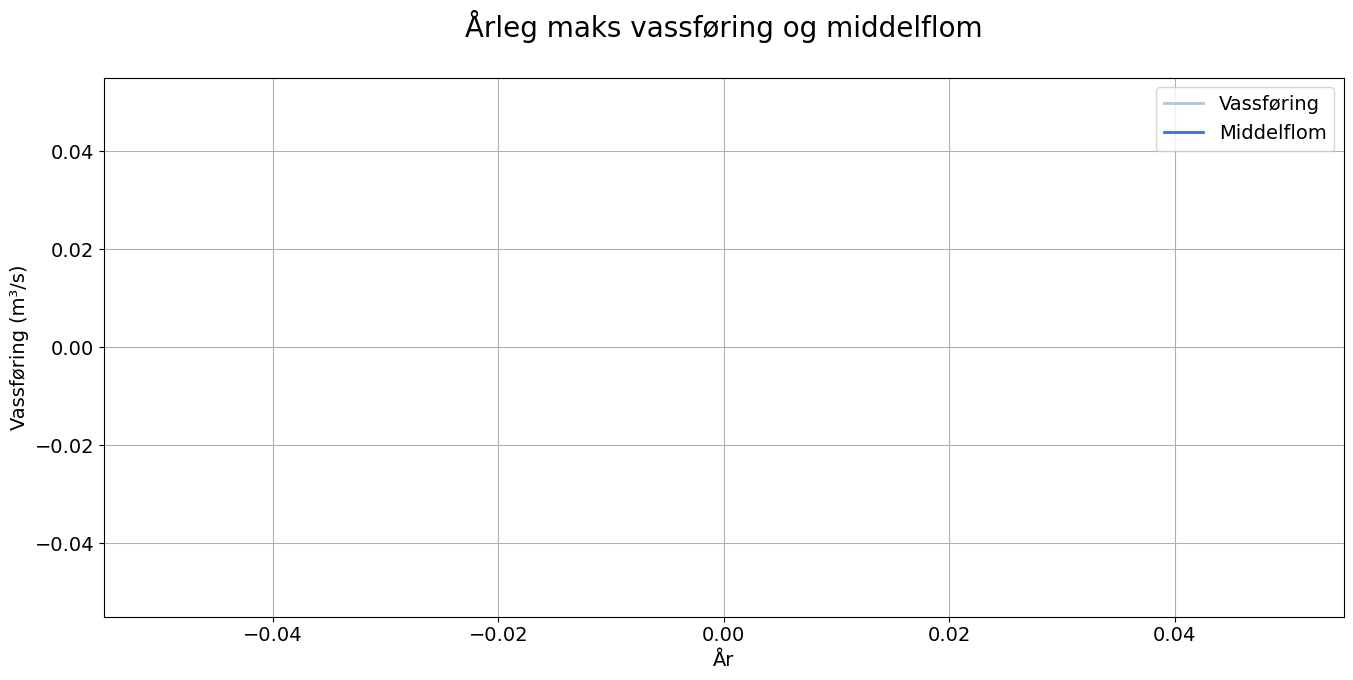

In [10]:
maksvf_og_middelflom.plot(
    figsize = (16, 7), 
    grid = True, 
    fontsize = 14, 
    linewidth = 2, 
    color = ["lightsteelblue", "royalblue"]
)

plt.title("Årleg maks vassføring og middelflom\n", fontsize = 20)
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.xlabel("År", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

### ✏️ Spørsmål

1. Går middelflommen opp eller ned over tid?

   *Svar:* 

2. Kva kan forklara denne trenden?

   *Svar:* 

### ✏️ Modify: Endre vindauget

Prøv å endra `window` til ulike verdiar og sjå korleis middelflom-kurva endrar seg.

Skriv inn ein ny verdi og køyr:

In [11]:
# Prøv ulike verdiar: 10, 20, 50
nytt_vindauge = ___

test_middelflom = årleg_vf_maks.copy()
test_middelflom["Middelflom"] = årleg_vf_maks.rolling(window = nytt_vindauge).mean()

test_middelflom.plot(
    figsize = (16, 7), 
    grid = True, 
    fontsize = 14, 
    linewidth = 2, 
    color = ["lightsteelblue", "royalblue"]
)

plt.title(f"Middelflom med vindauge = {nytt_vindauge} år\n", fontsize = 20)
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.xlabel("År", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

ValueError: window must be an integer 0 or greater

---
## Del 3: Flomlinjer og hydrogram

### 🔢 Lineær modell for middelflommen

<div class="alert alert-block alert-success">
<b>📐 Matematikk møter hydrologi:</b> Me finn ei rett linje (lineær modell) som beskriv korleis middelflommen endrar seg over tid — same type analyse som klimaforskarar brukar.
</div>

Middelflommen ser ut til å følgja ein rett linje (lineær trend). Me kan bruka `polyfit` til å finna denne linja.

In [ ]:
# Åra me har middelflom-data (frå og med 1959 — dvs. 30 år etter 1930, til og med 2025)
x = np.arange(1959, 2026) 

# Finn stigningstalet (a) og konstantleddet (b) for den rette linja
a, b = np.polyfit(x, maksvf_og_middelflom["Middelflom"].loc[1959:2025], 1)

# Definerer den lineære funksjonen
def f(x):
    return a * x + b

print(f"Modell: f(x) = {a:.3f} * x + {b:.1f}")
print(f"Middelflommen aukar med ca. {a:.2f} m³/s per år")

### ✏️ Flomlinjer frå NVE

Frå NVE sine flomdata for Reinsnosvatn kan me henta verdiar for ulike flomtypar.

<div class="alert alert-block alert-danger">
<b>⚠️ Vanleg misforståing:</b> Ein <b>20-årsflom</b> betyr <em>ikkje</em> at den skjer kvart 20. år. Det betyr <b>5% sjanse kvart einaste år</b> (1/20 = 0,05). Tenk på det som terningkast: du kan kasta to seksarar på rad, sjølv om sjansen er liten!
</div>

**Fyll inn verdiane frå NVE** og legg dei til i figuren:

In [ ]:
# Plottar dataa med trendlinje
maksvf_og_middelflom.plot(
    figsize = (16, 7), 
    grid = True, 
    fontsize = 14, 
    linewidth = 2, 
    color = ["lightsteelblue", "royalblue"]
)

plt.plot(x, f(x), linewidth = 2, label = "Modell for middelflom", color = "red")

# --- Fyll inn flomverdiar frå NVE ---

plt.axhline(y = 78.28, color = "crimson", linewidth = 2, linestyle = ":", label = "20-årsflom")

# Legg til fleire flomlinjer her:
# plt.axhline(y = ___, color = "orange", linewidth = 2, linestyle = ":", label = "50-årsflom")
# plt.axhline(y = ___, color = "darkred", linewidth = 2, linestyle = ":", label = "100-årsflom")
# plt.axhline(y = ___, color = "purple", linewidth = 2, linestyle = ":", label = "200-årsflom")

# -----------------------------------

plt.title("Vassføring, middelflom og flomlinjer\n", fontsize = 20)
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.xlabel("År", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

### ✏️ Spørsmål

1. Kor mange gonger har den årlege maksvassføringa vore over 20-årsflaumen? (Tel opp i figuren)

   *Svar:* 

2. Stemmer dette med at 20-årsflom har 5% sjanse per år?

   *Svar:* 

### Hydrogram — vassføring gjennom eit typisk år

No skal me sjå korleis vassføringa varierer gjennom eit **typisk år** i Reinsnosvatn.

Ideen: sorter alle målingane etter **dag i året** (1. jan = dag 1, 31. des = dag 365). Så reknar me ut medianen for kvar dag — det gir oss det typiske mønsteret.

**Denne koden er meir avansert — køyr cellene og fokuser på figuren.**

In [ ]:
# Legg til dag-i-året og årstal som eigne kolonner
df['doy'] = df.index.dayofyear
df['år'] = df.index.year

# Lag pivottabell: kvar rad er ein dag i året, kvar kolonne er eit år
piv = pd.pivot_table(df, index=['doy'], columns=['år'], values=['Vassføring'])

In [ ]:
# Rekn ut statistikk for kvar dag i året
piv["min"] = piv.min(axis = 1)
piv["maks"] = piv.max(axis = 1)
piv["75%"] = piv.quantile(q = 0.75, axis = 1)
piv["median"] = piv.median(axis = 1)
piv["25%"] = piv.quantile(q = 0.25, axis = 1)

### ✏️ Predict

**Før du køyrer neste celle:** Kor i året trur du vassføringa er høgast i Reinsnosvatn? Kvifor?

*Svar:* 

In [ ]:
# Plottar hydrogrammet

# Min- og maksverdiar
piv["min"].plot(
    figsize = (16, 7),
    color = "seagreen", 
    linewidth = 0.8, 
    fontsize = 14, 
    legend = False,
    label = "Minste verdi"
)

piv["maks"].plot(
    color = "seagreen", 
    linewidth = 0.8, 
    fontsize = 14, 
    legend = False,
    label = "Største verdi"
)

# Fargelegg området mellom 25- og 75-persentilane
plt.fill_between(
    piv.index, 
    piv["25%"], piv["75%"], 
    facecolor = 'green', 
    alpha = 0.2, 
    interpolate = True,
    label = "25% – 75%"
)

# Medianen (sjølve hydrogrammet)
piv["median"].plot(
    linewidth = 2, 
    color = "darkgreen",
    label = "Median"
)

# Norske månadsforkortingar på x-aksen
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mai', 'Jun',
                'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(month_ticks, month_labels, fontsize = 14)

plt.xlabel("")
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.title("Hydrogram — Reinsnosvatn\n", fontsize = 20)
plt.legend(fontsize = 14)
plt.show()

---
## Del 4: Di eiga elv

No skal du gjera det same med data frå ei elv du har valt sjølv.

### Steg for steg:
1. Gå til [sildre.nve.no](https://sildre.nve.no)
2. Finn ei elv du er nyfiken på — gjerne frå ein annan landsdel enn Vestland
3. Last ned **døgnvassføring** som CSV
4. Legg fila i same mappe som denne notatboka
5. Bruk koden under til å utforska dataa

<div class="alert alert-block alert-info">
<b>💡 Val av stasjon:</b> Vel ein stasjon med <b>minst 30 år med data</b> — elles vert middelflom-utrekninga upåliteleg. Sjekk lengda på dataserien på stasjonsida før du lastar ned.
</div>

### ✏️ Les inn dine data

Endre filnamnet til di eiga CSV-fil:

<div class="alert alert-block alert-warning">
<b>⚠️ Sjekk fila før du køyrer!</b> Opna CSV-fila i Notepad (Windows) eller TextEdit (Mac) og tell kor mange rader overskriften har. <code>skiprows=2</code> er vanlegvis riktig for NVE-data, men kan variera.
</div>

In [ ]:
# Endre filnamnet her:
mi_elv = pd.read_csv(
    "___FILNAMN___.csv",    # <-- Skriv inn filnamnet ditt
    sep = ";", 
    skiprows = 2, 
    names = ["dato", "Vassføring", "Korrigert", "Kontrollert"], 
    parse_dates = True, 
    decimal = ","
)

mi_elv.index = pd.to_datetime(mi_elv['dato']) 
mi_elv.index = pd.to_datetime(mi_elv.index.date)
mi_elv = mi_elv.drop(columns = ["dato", "Korrigert", "Kontrollert"])

mi_elv.tail()

### Årleg maks og middelflom

Tilpass årstala til ditt datasett:

### ✏️ Fyll inn: Avgrens ditt datasett

**Fyll inn startår og sluttår** for ditt datasett. Sjekk om det manglar data i periodar:

In [ ]:
mi_maks = mi_elv.groupby(by=[mi_elv.index.year]).max()

# Fyll inn startår og sluttår for ditt datasett:
mi_maks = mi_maks.loc[___:___]

mi_maks_og_middel = mi_maks.copy()
mi_maks_og_middel["Middelflom"] = mi_maks.rolling(window = 30).mean()

mi_maks_og_middel.plot(
    figsize = (16, 7), 
    grid = True, 
    fontsize = 14, 
    linewidth = 2, 
    color = ["lightsteelblue", "royalblue"]
)

plt.title("Årleg maks vassføring og middelflom — mi elv\n", fontsize = 20)
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.xlabel("År", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

### Flomlinjer

Slå opp flomtala for di elv på sildre.nve.no og legg dei inn:

### ✏️ Fyll inn: Flomverdiar frå NVE

Gå til [sildre.nve.no](https://sildre.nve.no), finn stasjonen for di elv, og slå opp flomtala. **Fyll inn verdiane under:**

In [ ]:
# Fyll inn flomverdiar frå NVE for di elv:
flom_20 = ___    # 20-årsflom
flom_50 = ___    # 50-årsflom  
flom_100 = ___   # 100-årsflom
flom_200 = ___   # 200-årsflom

mi_maks_og_middel.plot(
    figsize = (16, 7), 
    grid = True, 
    fontsize = 14, 
    linewidth = 2, 
    color = ["lightsteelblue", "royalblue"]
)

plt.axhline(y = flom_20, color = "crimson", linewidth = 2, linestyle = ":", label = "20-årsflom")
plt.axhline(y = flom_50, color = "orange", linewidth = 2, linestyle = ":", label = "50-årsflom")
plt.axhline(y = flom_100, color = "darkred", linewidth = 2, linestyle = ":", label = "100-årsflom")
plt.axhline(y = flom_200, color = "purple", linewidth = 2, linestyle = ":", label = "200-årsflom")

plt.title("Vassføring og flomlinjer — mi elv\n", fontsize = 20)
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.xlabel("År", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

### Hydrogram for di elv

Lag hydrogrammet for di elv. Bruk same framgangsmåte som i del 3:

In [ ]:
# Dag i året og årstal
mi_elv['doy'] = mi_elv.index.dayofyear
mi_elv['år'] = mi_elv.index.year

# Pivottabell
mi_piv = pd.pivot_table(mi_elv, index=['doy'], columns=['år'], values=['Vassføring'])

# Utrekningar
mi_piv["min"] = mi_piv.min(axis = 1)
mi_piv["maks"] = mi_piv.max(axis = 1)
mi_piv["75%"] = mi_piv.quantile(q = 0.75, axis = 1)
mi_piv["median"] = mi_piv.median(axis = 1)
mi_piv["25%"] = mi_piv.quantile(q = 0.25, axis = 1)

### ✏️ Rask refleksjon — hydrogrammet for di elv

**Før du går vidare til Del 5**, svar kort her:

1. Kva månad er toppen i vassføring? Kva kan forklara dette?

   *Svar:*

2. Kva er det mest overraskande med hydrogrammet samanlikna med Reinsnosvatn?

   *Svar:*

In [ ]:
# Plotta hydrogrammet
mi_piv["min"].plot(
    figsize = (16, 7),
    color = "seagreen", 
    linewidth = 0.8, 
    fontsize = 14, 
    legend = False,
    label = "Minste verdi"
)

mi_piv["maks"].plot(
    color = "seagreen", 
    linewidth = 0.8, 
    fontsize = 14, 
    legend = False,
    label = "Største verdi"
)

plt.fill_between(
    mi_piv.index, 
    mi_piv["25%"], mi_piv["75%"], 
    facecolor = 'green', 
    alpha = 0.2, 
    interpolate = True,
    label = "25% – 75%"
)

mi_piv["median"].plot(
    linewidth = 2, 
    color = "darkgreen",
    label = "Median"
)

# Norske månadsforkortingar på x-aksen
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mai', 'Jun',
                'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(month_ticks, month_labels, fontsize = 14)

plt.xlabel("")
plt.ylabel("Vassføring (m³/s)", fontsize = 14)
plt.title("Hydrogram — mi elv\n", fontsize = 20)   # <-- Endre til namnet på di elv
plt.legend(fontsize = 14)
plt.show()

---
## Del 5: Analyse og tolking

Skriv ein kort analyse av figurane du har laga. Bruk malen under.

### Mi elv

**Namn på elva og stasjon:** 

**Plassering (fylke, kommune):** 

**Kor lang er dataserien (frå–til)?** 

### Middelflom

Beskriv korleis middelflommen utviklar seg over tid for di elv. Går den opp, ned, eller er den stabil? Kva kan forklara trenden?

*Svar:* 

### Hydrogrammet

Beskriv hydrogrammet for di elv:

1. Kva månad(ar) er vassføringa høgast? Kva kan forklara dette?

   *Svar:* 

2. Kva månad(ar) er vassføringa lågast? Kvifor?

   *Svar:* 

3. Er variasjonen stor eller liten (det grøne feltet)? Kva seier det om elva?

   *Svar:* 

### Samanlikning med Reinsnosvatn

Samanlikn hydrogrammet for di elv med Reinsnosvatn:

1. Kva er likt?

   *Svar:* 

2. Kva er ulikt?

   *Svar:* 

3. Kva lokale tilhøve kan forklara skilnadene? (Tenk på: høgde over havet, bre, kyst/innland, regulering)

   *Svar:* 

### Flomvurdering

1. Kva er 100-årsflaumen for di elv (frå NVE)?

   *Svar:* 

2. Har den årlege maksvassføringa nokon gong vore over dette nivået?

   *Svar:* 

3. Kva betyr det eigentleg at noko er ein «100-årsflom»?

   *Svar:* 